
#**Followed Methodology**



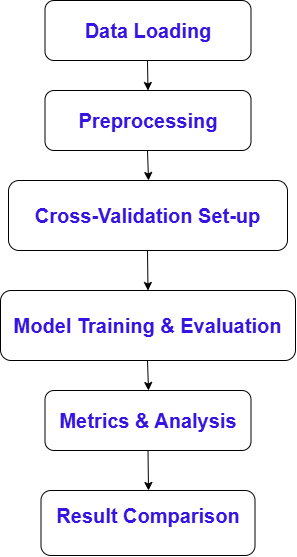

#**1: Load Dataset**

In [1]:
# Befor starting: *****************************
# Go to (Runtime).
# Choose (Change Runtime type).
# choose (T4 GPU)

# Re-install scanpy after restarting the runtime
!pip install scanpy

# Mount Google Drive first
from google.colab import drive
drive.mount('/content/drive')

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

print("Libraries imported. Google Drive is mounted.")

# MANUALLY TYPE THE PATH BASED ON WHAT YOU SEE IN THE FILE BROWSER
file_path = '/content/drive/MyDrive/Single-Cell Annotation Dataset/ts_pancreas.h5ad'

adata = sc.read_h5ad(file_path)
print("Dataset loaded successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Libraries imported. Google Drive is mounted.
Dataset loaded successfully!


# **2: Explore Dataset Structure**

Number of cells (observations): 14140
Number of genes (variables): 61759

Available metadata columns:
['donor_id', 'tissue_in_publication', 'anatomical_position', 'method', 'cdna_plate', 'library_plate', 'notes', 'cdna_well', 'assay_ontology_term_id', 'sample_id', 'replicate', '10X_run', 'ambient_removal', 'donor_method', 'donor_assay', 'donor_tissue', 'donor_tissue_assay', 'cell_type_ontology_term_id', 'compartment', 'broad_cell_class', 'free_annotation', 'manually_annotated', 'published_2022', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ercc', 'pct_counts_ercc', '_scvi_batch', '_scvi_labels', 'scvi_leiden_donorassay_full', 'ethnicity_original', 'scvi_leiden_res05_tissue', 'sample_number', 'suspension_type', 'tissue_type', 'disease_ontology_term_id', 'is_primary_data', 'tissue_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'ti

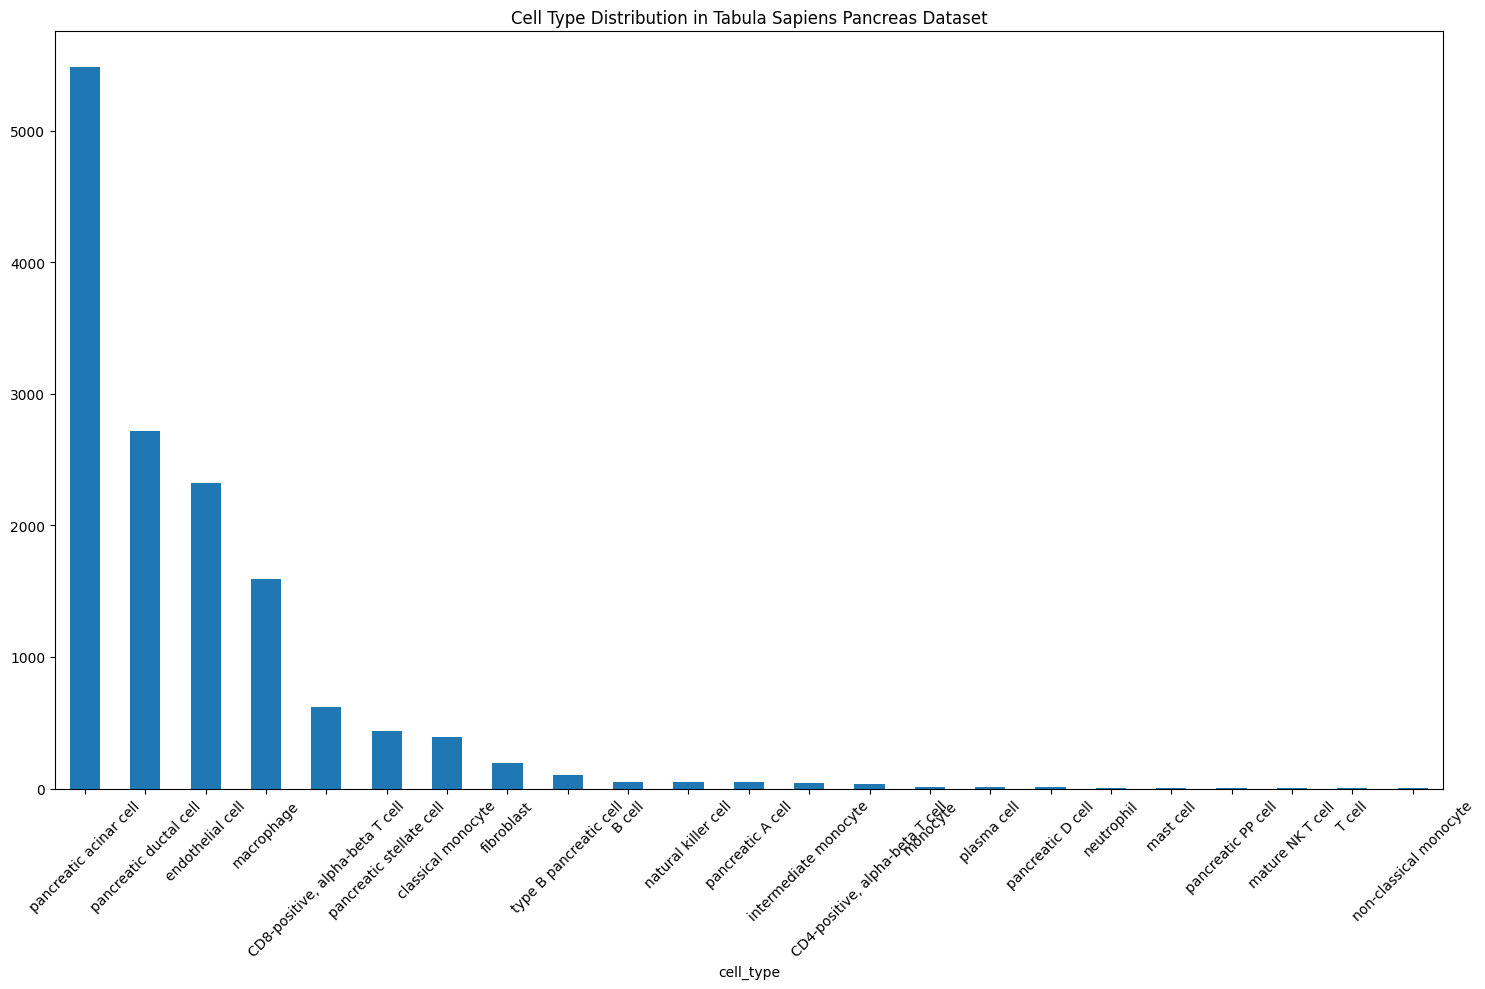

In [2]:
# Explore the basic structure of your dataset
print(f"Number of cells (observations): {adata.n_obs}")
print(f"Number of genes (variables): {adata.n_vars}")

# See what metadata is available for each cell (this is where 'cell_type' is stored)
print("\nAvailable metadata columns:")
print(adata.obs.columns.tolist())

# Check the unique cell types in this pancreas dataset
print("\nUnique cell types in this dataset:")
print(adata.obs['cell_type'].value_counts())

#summarize the dataset’s quality control (QC) metrics
print("\n Quality metrics summary:")
print(adata.obs[["n_genes_by_counts","total_counts","pct_counts_mt"]].describe().T)

# Optional: Visualize the distribution of cell types
import matplotlib.pyplot as plt
adata.obs['cell_type'].value_counts().plot(kind='bar', figsize=(15, 10))
plt.title('Cell Type Distribution in Tabula Sapiens Pancreas Dataset')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#**3: Preprocessing: Filtering & Normalization**

In [3]:
# 1. Basic filtering (standard for scRNA-seq data)
print("Filtering cells and genes...")
sc.pp.filter_cells(adata, min_genes=200)    # Remove cells with too few genes
sc.pp.filter_genes(adata, min_cells=3)      # Remove genes not found in enough cells

# 2. Normalize and scale the data (critical for model performance)
print("Normalizing and scaling data...")
sc.pp.normalize_total(adata, target_sum=1e4) # Normalize to 10,000 reads per cell
sc.pp.log1p(adata)                           # Log transform: log(1 + x)
sc.pp.scale(adata, max_value=10)             # Scale to mean=0, variance=1

# 3. Prepare features (X) and labels (y) for sklearn
print("Preparing features and labels for machine learning...")
X = adata.X                                  # The gene expression matrix (features)
y = adata.obs['cell_type']                   # The cell type labels (target)

# Check the final dimensions
print(f"\nFinal dataset shape: {X.shape}")
print(f"Number of unique labels: {y.nunique()}")

Filtering cells and genes...
Normalizing and scaling data...


/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Preparing features and labels for machine learning...

Final dataset shape: (14140, 37683)
Number of unique labels: 23


#**ُExplain the split problem**

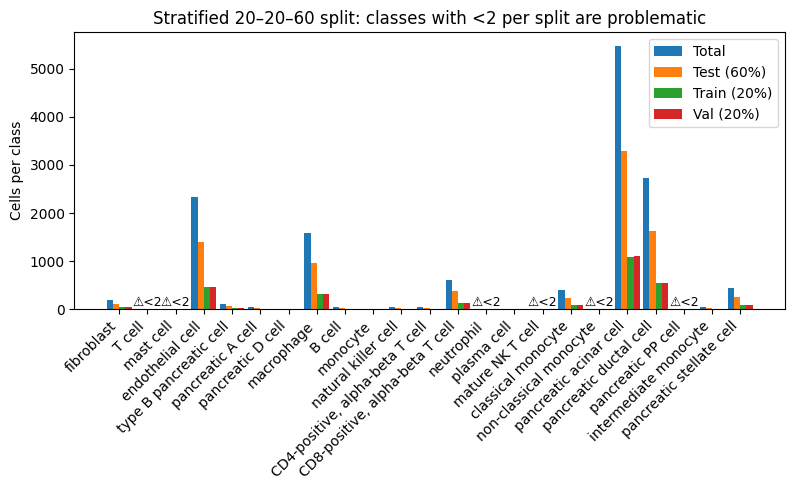

Saved diagram to: /content/stratified_split_violations.png

Per-class counts & violations:
                                 Total  Test (60%)  Train (20%)  Val (20%)  \
cell_type                                                                    
pancreatic acinar cell            5482        3289         1096       1097   
pancreatic ductal cell            2721        1633          544        544   
endothelial cell                  2325        1395          465        465   
macrophage                        1590         954          318        318   
CD8-positive, alpha-beta T cell    618         371          124        123   
pancreatic stellate cell           438         263           88         87   
classical monocyte                 390         234           78         78   
fibroblast                         194         116           39         39   
type B pancreatic cell             102          61           20         21   
B cell                              53          32 

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

#Safety checks
assert 'adata' in globals(), "adata was not found. Load your .h5ad first."
assert 'cell_type' in adata.obs.columns, "'cell_type' column not found in adata.obs."

#Actual class counts from your data
counts = adata.obs['cell_type'].value_counts().sort_index()

#Expected counts under a two-step 20–20–60
# First split: 40% temp (train+val) vs 60% test
temp = (counts * 0.40).round().astype(int)
test = (counts - temp).astype(int)

# Second split: temp -> 50/50 => 20% train, 20% val
train = (temp * 0.50).round().astype(int)
val = (temp - train).astype(int)

tbl = pd.DataFrame({
    "Total": counts,
    "Test (60%)": test,
    "Train (20%)": train,
    "Val (20%)": val
}).astype(int)

tbl["Min across splits"] = tbl[["Train (20%)","Val (20%)","Test (60%)"]].min(axis=1)
tbl["Violates stratify (min<2)"] = (tbl["Min across splits"] < 2)

#Plot grouped bars + flag violations
labels = tbl.index.tolist()
x = np.arange(len(labels))
w = 0.22

plt.figure(figsize=(max(8, len(labels)*0.35), 5))
plt.bar(x - w*1.5, tbl["Total"].values, width=w, label="Total")
plt.bar(x - w*0.5, tbl["Test (60%)"].values, width=w, label="Test (60%)")
plt.bar(x + w*0.5, tbl["Train (20%)"].values, width=w, label="Train (20%)")
plt.bar(x + w*1.5, tbl["Val (20%)"].values, width=w, label="Val (20%)")

# Mark classes that violate with a small warning tag
viol = tbl["Violates stratify (min<2)"].values
for i, bad in enumerate(viol):
    if bad:
        ymax = int(max(tbl.iloc[i][["Total","Test (60%)","Train (20%)","Val (20%)"]]))
        plt.text(x[i], ymax + max(1, int(ymax*0.03)), "⚠<2", ha='center', va='bottom', fontsize=9)

plt.xticks(x, labels, rotation=45, ha='right')
plt.title("Stratified 20–20–60 split: classes with <2 per split are problematic")
plt.ylabel("Cells per class")
plt.legend()
plt.tight_layout()

# Save a PNG
out_path = Path("/content/stratified_split_violations.png")
plt.savefig(out_path, dpi=200)
plt.show()

print(f"Saved diagram to: {out_path}")

#show a compact table
print("\nPer-class counts & violations:")
print(tbl.sort_values('Total', ascending=False).head(20))

#**The solution was to use Cross-Validation instead of splitting the data**

#**(KNN & RF) with Cross-Validation**

In [5]:
%%capture --no-stderr
!pip install -q scanpy

In [6]:
import io, contextlib
from google.colab import drive
_buf = io.StringIO()
with contextlib.redirect_stdout(_buf), contextlib.redirect_stderr(_buf):
    drive.mount('/content/drive', force_remount=False)

In [7]:
# ============================================
# Full CV pipeline for KNN & Random Forest
# Takes:
# - Large scRNA-seq datasets (Tabula Sapiens Pancreas)
# - Class imbalance (merges rare cell types)
# - Memory optimization (uses HVGs + limited parallel jobs)
# ============================================
import warnings
from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

import numpy as np, pandas as pd, scanpy as sc
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

sc.settings.verbosity = 0

# Load data
file_path = '/content/drive/MyDrive/Single-Cell Annotation Dataset/ts_pancreas.h5ad'
adata = sc.read_h5ad(file_path)
print(f"Dataset loaded: {adata.n_obs} cells × {adata.n_vars} genes")

# HVGs
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata = adata[:, adata.var['highly_variable']]
X = adata.X.toarray() if not isinstance(adata.X, np.ndarray) else adata.X
y = adata.obs['cell_type'].values
print(f"Reduced to HVGs: {adata.n_obs} × {adata.n_vars}")

# Merge ultra-rare classes (<5)
counts = pd.Series(y).value_counts()
rare = counts[counts < 5].index
if len(rare) > 0:
    y = np.where(np.isin(y, rare), 'Rare_Other', y)
    print(f"Merged {len(rare)} rare classes → 'Rare_Other'")

# CV + models
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']

knn = Pipeline([("scaler", StandardScaler(with_mean=False)),
                ("clf", KNeighborsClassifier(n_neighbors=15, weights='distance', metric='cosine'))])

rf  = Pipeline([("clf", RandomForestClassifier(n_estimators=400, class_weight="balanced",
                                               random_state=42, n_jobs=-1))])

print("\nRunning 5-Fold CV…")
knn_scores = cross_validate(knn, X, y, cv=skf, scoring=scoring, n_jobs=2, return_train_score=False)
rf_scores  = cross_validate(rf,  X, y, cv=skf, scoring=scoring, n_jobs=2, return_train_score=False)

def summarize(name, s):
    print(f"\n=== {name} (5-Fold CV) ===")
    print(f"Accuracy       : {s['test_accuracy'].mean():.4f}")
    print(f"F1-macro       : {s['test_f1_macro'].mean():.4f}")
    print(f"Precision-macro: {s['test_precision_macro'].mean():.4f}")
    print(f"Recall-macro   : {s['test_recall_macro'].mean():.4f}")

summarize("KNN (cosine, distance-weighted, k=15)", knn_scores)
summarize("Random Forest (balanced, 400 trees)", rf_scores)

Dataset loaded: 14140 cells × 61759 genes
Reduced to HVGs: 14140 × 2000
Merged 5 rare classes → 'Rare_Other'

Running 5-Fold CV…

=== KNN (cosine, distance-weighted, k=15) (5-Fold CV) ===
Accuracy       : 0.9540
F1-macro       : 0.6730
Precision-macro: 0.7142
Recall-macro   : 0.6659

=== Random Forest (balanced, 400 trees) (5-Fold CV) ===
Accuracy       : 0.9673
F1-macro       : 0.6732
Precision-macro: 0.6755
Recall-macro   : 0.6738


#**per-class report and confusion matrix heatmap**


=== KNN (cosine, distance-weighted, k=15) ===


,precision,recall,f1-score,support
B cell,0.943000,0.943000,0.943000,53.000000
"CD4-positive, alpha-beta T cell",0.833000,0.135000,0.233000,37.000000
"CD8-positive, alpha-beta T cell",0.949000,0.992000,0.970000,618.000000
Rare_Other,0.000000,0.000000,0.000000,8.000000
classical monocyte,0.737000,0.864000,0.796000,390.000000
endothelial cell,0.995000,0.987000,0.991000,2325.000000
fibroblast,0.949000,0.861000,0.903000,194.000000
intermediate monocyte,0.333000,0.024000,0.044000,42.000000
macrophage,0.932000,0.935000,0.933000,1590.000000
monocyte,1.000000,0.077000,0.143000,13.000000


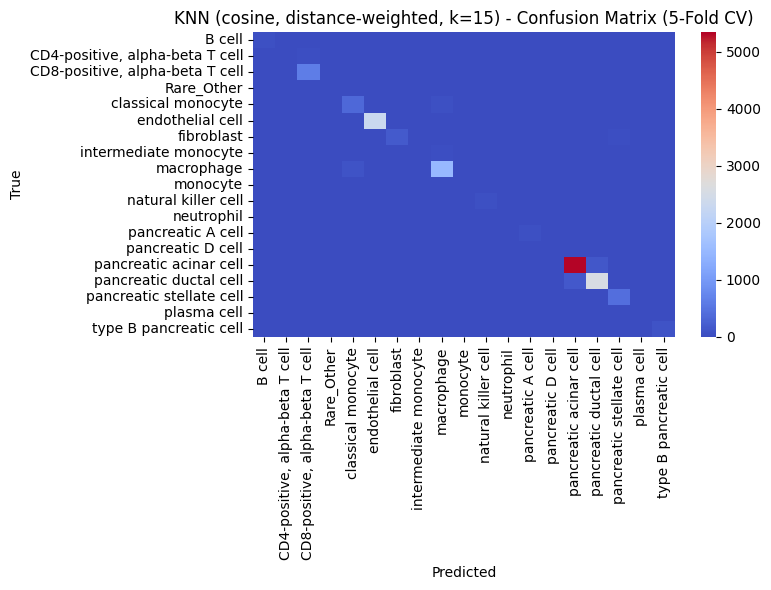


=== Random Forest (balanced, 400 trees) ===


,precision,recall,f1-score,support
B cell,0.981000,1.000000,0.991000,53.000000
"CD4-positive, alpha-beta T cell",0.000000,0.000000,0.000000,37.000000
"CD8-positive, alpha-beta T cell",0.933000,0.998000,0.965000,618.000000
Rare_Other,0.000000,0.000000,0.000000,8.000000
classical monocyte,0.839000,0.790000,0.814000,390.000000
endothelial cell,0.997000,0.997000,0.997000,2325.000000
fibroblast,0.995000,0.964000,0.979000,194.000000
intermediate monocyte,0.000000,0.000000,0.000000,42.000000
macrophage,0.919000,0.972000,0.945000,1590.000000
monocyte,0.000000,0.000000,0.000000,13.000000


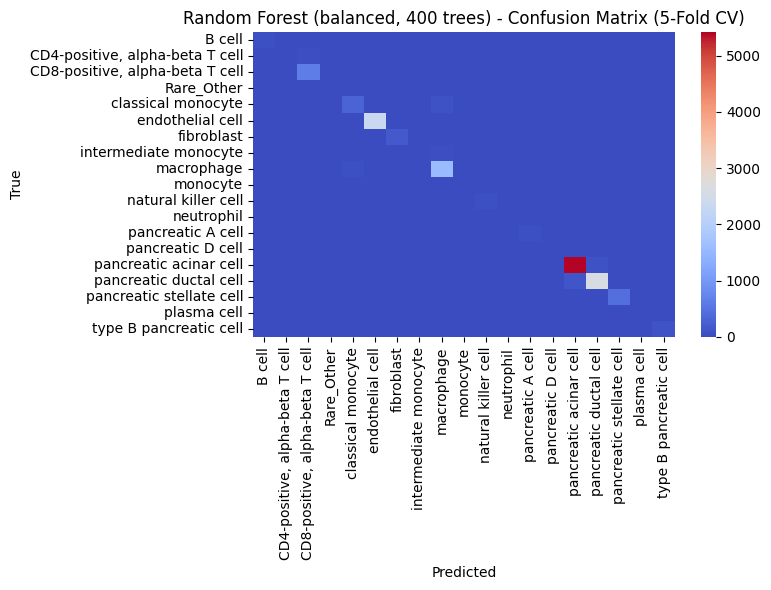

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

#Reuse existing X, y
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_pretty(name, pipe):
    print(f"\n=== {name} ===")
    y_pred = cross_val_predict(pipe, X, y, cv=skf, n_jobs=2, method="predict")

    #classification report as DataFrame
    report = classification_report(y, y_pred, output_dict=True, zero_division=0)
    df_report = pd.DataFrame(report).T
    df_report = df_report.round(3)
    df_report_style = df_report.style.background_gradient(
        cmap="Blues", subset=["precision", "recall", "f1-score"]
    )
    display(df_report_style)

    #confusion matrix heatmap
    labels = sorted(list(set(y)))
    cm = confusion_matrix(y, y_pred, labels=labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=False, fmt="d", cmap="coolwarm",
                xticklabels=labels, yticklabels=labels)
    plt.title(f"{name} - Confusion Matrix (5-Fold CV)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

# Define the models
knn_pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("clf", KNeighborsClassifier(n_neighbors=15, weights='distance', metric='cosine'))
])

rf_pipe = Pipeline([
    ("clf", RandomForestClassifier(
        n_estimators=400,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

# Evaluate both with visual output
evaluate_pretty("KNN (cosine, distance-weighted, k=15)", knn_pipe)
evaluate_pretty("Random Forest (balanced, 400 trees)", rf_pipe)

#**Setup PyTorch & shared helpers**

In [9]:
import numpy as np
import torch, torch.nn as nn, torch.optim as optim
from sklearn.preprocessing import StandardScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch device:", device)

# Reuse X, y from the previous cells (after HVGs selection and rare-class merge if applied)
# Make sure X is dense and float32
X_dense = X if isinstance(X, np.ndarray) else X.toarray()
X_dense = X_dense.astype(np.float32)
n_cells, n_genes = X_dense.shape
print(f"Input for Transformer: {n_cells} cells × {n_genes} genes")

#Standardize inputs once for SSL
ssl_scaler = StandardScaler(with_mean=True, with_std=True)
X_std = ssl_scaler.fit_transform(X_dense).astype(np.float32)

Torch device: cpu
Input for Transformer: 14140 cells × 2000 genes


#**Transformer self-supervised pipeline**

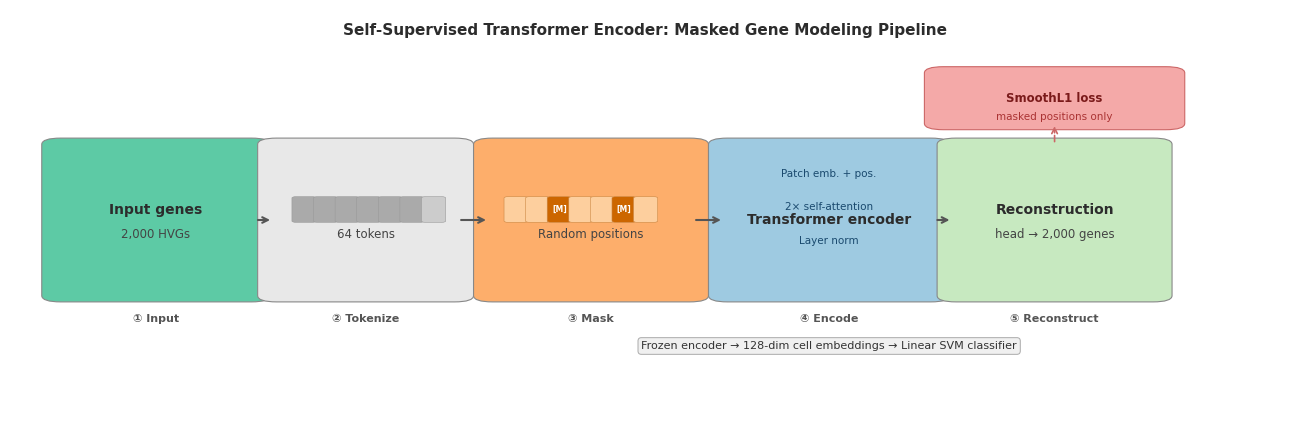

Saved: transformer_ssl_pipeline.png


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.axis("off")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

C_TEAL   = "#5DCAA5"
C_ORANGE = "#fdae6b"
C_BLUE   = "#9ecae1"
C_GREEN  = "#c7e9c0"
C_RED    = "#f4a9a8"
C_GRAY   = "#e8e8e8"
C_DARK   = "#2c2c2c"
C_ARROW  = "#555555"

def draw_box(ax, x, y, w, h, color, title, subtitle=None, title_size=10, sub_size=8.5):
    box = mpatches.FancyBboxPatch((x, y), w, h,
                                   boxstyle="round,pad=0.015",
                                   facecolor=color, edgecolor="#888888",
                                   linewidth=0.8, zorder=3)
    ax.add_patch(box)
    ty = y + h / 2 + (0.025 if subtitle else 0)
    ax.text(x + w/2, ty, title, ha='center', va='center',
            fontsize=title_size, fontweight='bold', color=C_DARK, zorder=4)
    if subtitle:
        ax.text(x + w/2, y + h/2 - 0.035, subtitle, ha='center', va='center',
                fontsize=sub_size, color="#444444", zorder=4)

def draw_arrow(ax, x1, x2, y=0.5):
    ax.annotate('', xy=(x2, y), xytext=(x1, y),
                arrowprops=dict(arrowstyle='->', color=C_ARROW,
                                lw=1.5, connectionstyle='arc3,rad=0'))

Y      = 0.32
H      = 0.36
stages = [0.04, 0.21, 0.38, 0.565, 0.745]
W      = [0.15, 0.14, 0.155, 0.16, 0.155]

# 1. Input genes
draw_box(ax, stages[0], Y, W[0], H, C_TEAL, "Input genes", "2,000 HVGs")

# 2. Patchify
draw_box(ax, stages[1], Y, W[1], H, C_GRAY, "Patchify", "64 tokens")
tile_w, tile_h = 0.013, 0.055
for i in range(7):
    tx = stages[1] + 0.015 + i * (tile_w + 0.004)
    ty = Y + H/2 - tile_h/2 + 0.025
    color = "#aaaaaa" if i < 6 else "#cccccc"
    tile = mpatches.FancyBboxPatch((tx, ty), tile_w, tile_h,
                                    boxstyle="round,pad=0.003",
                                    facecolor=color, edgecolor="#999999",
                                    linewidth=0.4, zorder=5)
    ax.add_patch(tile)

# 3. Masking
draw_box(ax, stages[2], Y, W[2], H, C_ORANGE, "Mask 15%", "Random positions")
for i in range(7):
    tx = stages[2] + 0.012 + i * (tile_w + 0.004)
    ty = Y + H/2 - tile_h/2 + 0.025
    is_masked = i in [2, 5]
    color = "#cc6600" if is_masked else "#fdcf9e"
    tile = mpatches.FancyBboxPatch((tx, ty), tile_w, tile_h,
                                    boxstyle="round,pad=0.003",
                                    facecolor=color, edgecolor="#cc8844",
                                    linewidth=0.4, zorder=5)
    ax.add_patch(tile)
    if is_masked:
        ax.text(tx + tile_w/2, ty + tile_h/2, "[M]",
                ha='center', va='center',
                fontsize=5.5, color="white", fontweight='bold', zorder=6)

# 4. Transformer encoder
draw_box(ax, stages[3], Y, W[3], H, C_BLUE, "Transformer encoder", None)
for i, lbl in enumerate(["Patch emb. + pos.", "2× self-attention", "Layer norm"]):
    ax.text(stages[3] + W[3]/2, Y + H - 0.07 - i*0.08, lbl,
            ha='center', va='center', fontsize=7.5, color="#1a4a6e", zorder=5)

# 5. Reconstruction
draw_box(ax, stages[4], Y, W[4], H, C_GREEN, "Reconstruction", "head → 2,000 genes")

# Loss box (above reconstruction)
loss_x = stages[4] + W[4]/2
loss_box = mpatches.FancyBboxPatch((stages[4] - 0.01, Y + H + 0.05),
                                    W[4] + 0.02, 0.12,
                                    boxstyle="round,pad=0.015",
                                    facecolor=C_RED, edgecolor="#cc6666",
                                    linewidth=0.8, zorder=3)
ax.add_patch(loss_box)
ax.text(loss_x, Y + H + 0.11, "SmoothL1 loss",
        ha='center', va='center', fontsize=8.5,
        fontweight='bold', color="#7a1a1a", zorder=4)
ax.text(loss_x, Y + H + 0.065, "masked positions only",
        ha='center', va='center', fontsize=7.5, color="#aa3333", zorder=4)
ax.annotate('', xy=(loss_x, Y + H + 0.05), xytext=(loss_x, Y + H),
            arrowprops=dict(arrowstyle='->', color="#cc6666",
                            lw=1.2, linestyle='dashed'))

# Downstream note
ax.text(stages[3] + W[3]/2, Y - 0.12,
        "Frozen encoder → 128-dim cell embeddings → Linear SVM classifier",
        ha='center', va='center', fontsize=8, color="#333333",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#f0f0f0",
                  edgecolor="#aaaaaa", linewidth=0.7))

# Arrows between stages
arrow_y = Y + H/2
for x1, x2 in [(stages[i] + W[i], stages[i+1]) for i in range(4)]:
    draw_arrow(ax, x1 + 0.003, x2 - 0.003, y=arrow_y)

# Stage labels — single loop, all below boxes, consistent
for x, w, lbl in zip(stages, W, [
    "① Input", "② Tokenize", "③ Mask", "④ Encode", "⑤ Reconstruct"
]):
    ax.text(x + w/2, Y - 0.055, lbl,
            ha='center', va='center',
            fontsize=8, color="#555555", fontweight='bold')

# Title
ax.text(0.5, 0.97,
        "Self-Supervised Transformer Encoder: Masked Gene Modeling Pipeline",
        ha='center', va='top', fontsize=11, fontweight='bold', color=C_DARK)

plt.tight_layout()
plt.savefig("transformer_ssl_pipeline.png", dpi=400, bbox_inches="tight",
            facecolor="white")
plt.show()
print("Saved: transformer_ssl_pipeline.png")

#**Build a Lightweight Transformer (Gene Patches)**

In [11]:
#Patch genes into tokens (64 tokens)
#Tiny encoder for fast training

import math

class Patchify(nn.Module):
    """Split gene vector into equal-sized patches (tokens)."""
    def __init__(self, n_genes: int, n_tokens: int):
        super().__init__()
        self.n_tokens = n_tokens
        self.patch_size = math.ceil(n_genes / n_tokens)
        self.total = self.patch_size * self.n_tokens  # padded length

    def forward(self, x):  # x: (B, n_genes)
        B, G = x.shape
        if G < self.total:
            pad = self.total - G
            x = torch.nn.functional.pad(x, (0, pad))
        # (B, n_tokens, patch_size)
        x = x.view(B, self.n_tokens, self.patch_size)
        return x

class Unpatchify(nn.Module):
    """Reconstruct gene vector from tokens (trim padding)."""
    def __init__(self, n_genes: int, n_tokens: int):
        super().__init__()
        self.n_tokens = n_tokens
        self.patch_size = math.ceil(n_genes / n_tokens)
        self.n_genes = n_genes
        self.total = self.patch_size * self.n_tokens

    def forward(self, x_tokens):  # (B, n_tokens, patch_size)
        B, T, P = x_tokens.shape
        x = x_tokens.reshape(B, T * P)
        return x[:, :self.n_genes]

class GeneTransformer(nn.Module):
    def __init__(self, n_genes, n_tokens=64, d_model=128, n_heads=4, n_layers=2, p_drop=0.1):
        super().__init__()
        self.n_genes = n_genes
        self.n_tokens = n_tokens
        self.patchify = Patchify(n_genes, n_tokens)
        self.unpatchify = Unpatchify(n_genes, n_tokens)

        # Patch embedding: linear per patch
        self.patch_emb = nn.Linear(self.patchify.patch_size, d_model)

        # Positional embeddings
        self.pos = nn.Parameter(torch.zeros(1, n_tokens, d_model))

        # Transformer encoder
        enc_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, batch_first=True, dropout=p_drop)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)

        # Reconstruction head: token -> patch values
        self.head = nn.Linear(d_model, self.patchify.patch_size)

        # For pooling embeddings (CLS-like via mean)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):  # x: (B, n_genes)
        patches = self.patchify(x)                                # (B, T, P)
        h = self.patch_emb(patches) + self.pos                    # (B, T, d)
        h = self.encoder(h)                                       # (B, T, d)
        rec_patches = self.head(h)                                # (B, T, P)
        rec = self.unpatchify(rec_patches)                        # (B, n_genes)
        # Pooled embedding for downstream (mean over tokens):
        emb = self.norm(h.mean(dim=1))                            # (B, d)
        return rec, emb

#**Self-Supervised Pretraining (Masked Gene Modeling)**

In [12]:
#Mask ~15% of genes, reconstruct only masked
#10 epochs are enough for a good boost

mask_ratio = 0.15
epochs = 30
batch_size = 256
lr = 1e-3
weight_decay = 1e-4

model = GeneTransformer(n_genes=n_genes, n_tokens=64, d_model=256, n_heads=8, n_layers=4, p_drop=0.1).to(device)
opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
loss_fn = nn.SmoothL1Loss()  # Huber-like #robust on scRNA-seq

# Prebuild index batches for speed
idx_all = np.arange(n_cells)

def batch_iter(bs=256):
    np.random.shuffle(idx_all)
    for i in range(0, len(idx_all), bs):
        yield idx_all[i:i+bs]

for ep in range(1, epochs+1):
    model.train()
    total = 0.0
    for idx in batch_iter(batch_size):
        xb = torch.from_numpy(X_std[idx]).to(device)      # (B, n_genes)
        # Random mask per element
        mask = (torch.rand_like(xb) < mask_ratio).float()
        noisy = xb * (1 - mask)                           # zero the masked positions
        rec, _ = model(noisy)
        # Loss only on masked entries
        loss = loss_fn(rec * mask, xb * mask)

        opt.zero_grad()
        loss.backward()
        opt.step()
        total += loss.item()
    print(f"[SSL pretrain] epoch {ep:02d}/{epochs} | loss={total:.4f}")

# Save encoder weights + scaler to reuse at inference
#torch.save(model.state_dict(), "/content/transformer_encoder.pt")
print("Saved: /content/transformer_encoder.pt")
torch.save(model.state_dict(), "/content/drive/MyDrive/transformer_checkpoint.pt")

[SSL pretrain] epoch 01/30 | loss=1.5555
[SSL pretrain] epoch 02/30 | loss=1.3494
[SSL pretrain] epoch 03/30 | loss=1.3200
[SSL pretrain] epoch 04/30 | loss=1.3048
[SSL pretrain] epoch 05/30 | loss=1.3049
[SSL pretrain] epoch 06/30 | loss=1.3098
[SSL pretrain] epoch 07/30 | loss=1.2951
[SSL pretrain] epoch 08/30 | loss=1.2916
[SSL pretrain] epoch 09/30 | loss=1.2960
[SSL pretrain] epoch 10/30 | loss=1.2861
[SSL pretrain] epoch 11/30 | loss=1.2633
[SSL pretrain] epoch 12/30 | loss=1.2336
[SSL pretrain] epoch 13/30 | loss=1.1871
[SSL pretrain] epoch 14/30 | loss=1.1594
[SSL pretrain] epoch 15/30 | loss=1.1255
[SSL pretrain] epoch 16/30 | loss=1.0973
[SSL pretrain] epoch 17/30 | loss=1.0808
[SSL pretrain] epoch 18/30 | loss=1.0477
[SSL pretrain] epoch 19/30 | loss=1.0373
[SSL pretrain] epoch 20/30 | loss=1.0315
[SSL pretrain] epoch 21/30 | loss=1.0181
[SSL pretrain] epoch 22/30 | loss=1.0132
[SSL pretrain] epoch 23/30 | loss=1.0010
[SSL pretrain] epoch 24/30 | loss=1.0005
[SSL pretrain] e

#**Freeze Encoder & Build an Embedding Featurizer**

In [13]:
#Turn cells into d_model embeddings (batch-wise)
#Use in an sklearn Pipeline (Linear Probe)

from sklearn.base import BaseEstimator, TransformerMixin

# Reload a frozen copy for inference
_frozen = GeneTransformer(n_genes=n_genes, n_tokens=64, d_model=256, n_heads=8, n_layers=4, p_drop=0.0).to(device)
_frozen.load_state_dict(torch.load("/content/transformer_encoder.pt", map_location=device))
_frozen.eval()
for p in _frozen.parameters():
    p.requires_grad = False

class TransformerEmbedder(BaseEstimator, TransformerMixin):
    """Sklearn-compatible featurizer that returns (n_samples, d_model) embeddings."""
    def __init__(self, batch_size=512):
        self.batch_size = batch_size

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # Ensure numpy float32
        X_arr = X if isinstance(X, np.ndarray) else X.toarray()
        X_arr = X_arr.astype(np.float32)
        # Use the same scaler from SSL pretraining
        X_arr = ssl_scaler.transform(X_arr).astype(np.float32)

        embs = []
        with torch.no_grad():
            for i in range(0, X_arr.shape[0], self.batch_size):
                xb = torch.from_numpy(X_arr[i:i+self.batch_size]).to(device)
                _, e = _frozen(xb)
                embs.append(e.cpu().numpy())
        return np.concatenate(embs, axis=0)

#**Cross-Validation with Transformer (Linear Probe)**

In [14]:
#Same protocol as KNN/RF
#LogisticRegression balanced as the classifier

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']

transformer_pipe = Pipeline([
    ("embed", TransformerEmbedder(batch_size=512)),        # frozen encoder -> embeddings
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", n_jobs=-1))
])

print("\nRunning 5-Fold CV (Transformer Linear Probe)…")
tr_scores = cross_validate(transformer_pipe, X_dense, y, cv=skf,
                           scoring=scoring, n_jobs=2, return_train_score=False)

print("\n=== Transformer (self-pretrained, linear probe) — 5-Fold CV ===")
print(f"Accuracy       : {tr_scores['test_accuracy'].mean():.4f}")
print(f"F1-macro       : {tr_scores['test_f1_macro'].mean():.4f}")
print(f"Precision-macro: {tr_scores['test_precision_macro'].mean():.4f}")
print(f"Recall-macro   : {tr_scores['test_recall_macro'].mean():.4f}")


Running 5-Fold CV (Transformer Linear Probe)…

=== Transformer (self-pretrained, linear probe) — 5-Fold CV ===
Accuracy       : 0.9496
F1-macro       : 0.7630
Precision-macro: 0.7477
Recall-macro   : 0.8378


#**Per-class report & Confusion Matrix (Transformer)**

,precision,recall,f1-score,support
B cell,0.914000,1.000000,0.955000,53.000000
"CD4-positive, alpha-beta T cell",0.304000,0.568000,0.396000,37.000000
"CD8-positive, alpha-beta T cell",0.973000,0.917000,0.944000,618.000000
Rare_Other,0.091000,0.125000,0.105000,8.000000
classical monocyte,0.771000,0.831000,0.800000,390.000000
endothelial cell,0.996000,0.995000,0.995000,2325.000000
fibroblast,0.969000,0.979000,0.974000,194.000000
intermediate monocyte,0.139000,0.810000,0.238000,42.000000
macrophage,0.981000,0.816000,0.891000,1590.000000
monocyte,0.283000,1.000000,0.441000,13.000000


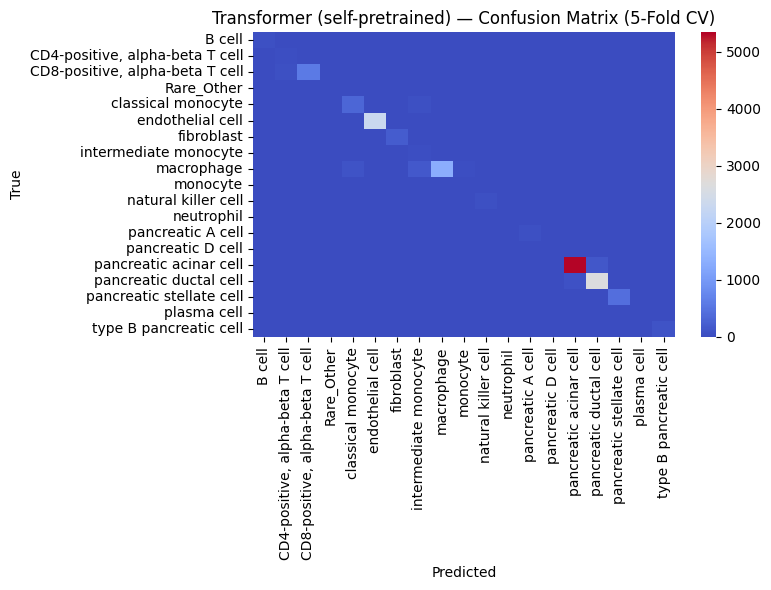

In [15]:
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

y_pred_tr = cross_val_predict(transformer_pipe, X_dense, y, cv=skf, n_jobs=2, method="predict")

report = classification_report(y, y_pred_tr, output_dict=True, zero_division=0)
df_report = pd.DataFrame(report).T.round(3)
display(df_report.style.background_gradient(cmap="Blues", subset=["precision","recall","f1-score"]))

labels = sorted(list(set(y)))
cm = confusion_matrix(y, y_pred_tr, labels=labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, fmt="d", cmap="coolwarm",
            xticklabels=labels, yticklabels=labels)
plt.title("Transformer (self-pretrained) — Confusion Matrix (5-Fold CV)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

#**Hybrid Model: Transformer + SVM**

In [16]:
from sklearn.svm import LinearSVC

svm_clf = LinearSVC(class_weight="balanced", max_iter=5000)

transformer_svm_pipe = Pipeline([
    ("embed", TransformerEmbedder(batch_size=512)),
    ("svm", svm_clf)
])

print("\nRunning 5-Fold CV (Transformer + SVM)…")
svm_scores = cross_validate(
    transformer_svm_pipe, X_dense, y,
    cv=skf, scoring=scoring,
    n_jobs=2, return_train_score=False
)

print("\n=== Hybrid Model (Transformer + SVM) — 5-Fold CV ===")
print(f"Accuracy       : {svm_scores['test_accuracy'].mean():.4f}")
print(f"F1-macro       : {svm_scores['test_f1_macro'].mean():.4f}")
print(f"Precision-macro: {svm_scores['test_precision_macro'].mean():.4f}")
print(f"Recall-macro   : {svm_scores['test_recall_macro'].mean():.4f}")


Running 5-Fold CV (Transformer + SVM)…

=== Hybrid Model (Transformer + SVM) — 5-Fold CV ===
Accuracy       : 0.9636
F1-macro       : 0.7759
Precision-macro: 0.7909
Recall-macro   : 0.7852


#**Per-class report & Confusion Matrix (Transformer + SVM)**

Running cross-validated predictions for Transformer + SVM …


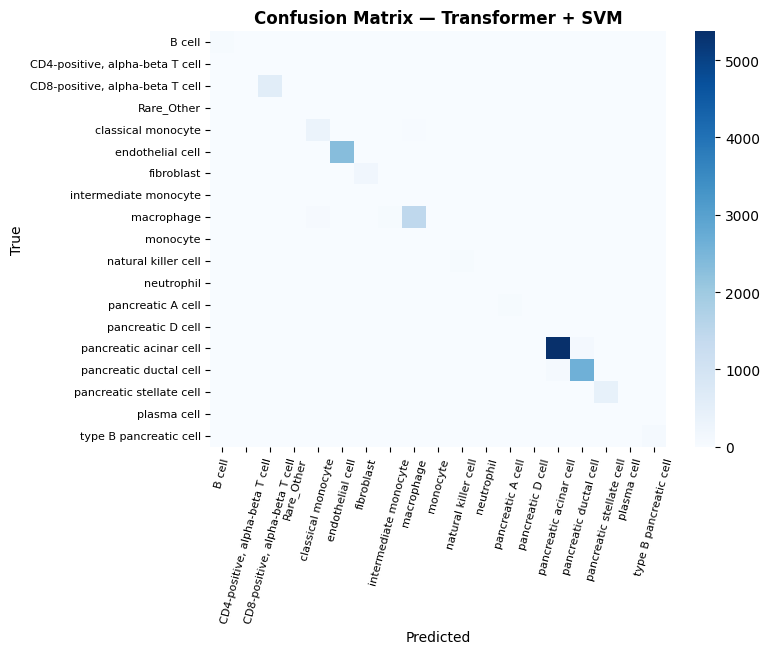


=== Classification report — Transformer + SVM ===
                                 precision    recall  f1-score   support

                         B cell      0.946     1.000     0.972        53
CD4-positive, alpha-beta T cell      0.560     0.378     0.452        37
CD8-positive, alpha-beta T cell      0.962     0.981     0.971       618
                     Rare_Other      0.333     0.125     0.182         8
             classical monocyte      0.790     0.859     0.823       390
               endothelial cell      0.997     0.996     0.996      2325
                     fibroblast      0.974     0.974     0.974       194
          intermediate monocyte      0.189     0.405     0.258        42
                     macrophage      0.959     0.911     0.934      1590
                       monocyte      0.529     0.692     0.600        13
            natural killer cell      0.960     0.960     0.960        50
                     neutrophil      0.750     0.429     0.545         7

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import cross_val_predict

# 1) Ensure labels are a clean 1D string array
y_true = np.asarray(y).ravel().astype(str)

# 2) Cross-validated predictions for the hybrid model
print("Running cross-validated predictions for Transformer + SVM …")
y_pred_hyb = cross_val_predict(
    transformer_svm_pipe,   # hybrid Pipeline
    X,                      # features (sparse or dense; pipeline handles both)
    y_true,
    cv=skf,
    n_jobs=2,
    method="predict"
)

# 3) Build class list and confusion matrix
classes = sorted(np.unique(y_true))
cm = confusion_matrix(y_true, y_pred_hyb, labels=classes)

# 4) Plot confusion matrix heatmap for the hybrid model only
fig_height = max(6, 0.35 * len(classes))
fig_width  = max(8, 0.4 * len(classes))

plt.figure(figsize=(fig_width, fig_height))
sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
    cbar=True
)
plt.title("Confusion Matrix — Transformer + SVM", fontsize=12, weight="bold")
plt.xlabel("Predicted", fontsize=10)
plt.ylabel("True", fontsize=10)
plt.xticks(rotation=75, fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig("confusion_matrix_transformer_svm.png", dpi=400, bbox_inches="tight")
plt.show()

# 5) Per-class precision / recall / F1 report
print("\n=== Classification report — Transformer + SVM ===")
print(classification_report(y_true, y_pred_hyb, target_names=classes, digits=3))

# **SVM on raw HVGs (ablation baseline)**


In [20]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']

svm_raw_pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("svm", LinearSVC(class_weight="balanced", max_iter=5000))
])

svm_raw_scores = cross_validate(svm_raw_pipe, X, y, cv=skf,
                                scoring=scoring, n_jobs=2,
                                return_train_score=False)

print("=== SVM on raw HVGs (ablation) ===")
print(f"Accuracy        : {svm_raw_scores['test_accuracy'].mean():.4f} ± {svm_raw_scores['test_accuracy'].std():.4f}")
print(f"F1-macro        : {svm_raw_scores['test_f1_macro'].mean():.4f} ± {svm_raw_scores['test_f1_macro'].std():.4f}")
print(f"Precision-macro : {svm_raw_scores['test_precision_macro'].mean():.4f} ± {svm_raw_scores['test_precision_macro'].std():.4f}")
print(f"Recall-macro    : {svm_raw_scores['test_recall_macro'].mean():.4f} ± {svm_raw_scores['test_recall_macro'].std():.4f}")

=== SVM on raw HVGs (ablation) ===
Accuracy        : 0.9503 ± 0.0015
F1-macro        : 0.7318 ± 0.0453
Precision-macro : 0.7499 ± 0.0519
Recall-macro    : 0.7283 ± 0.0384


# **Standard deviation for ALL existing models**

In [21]:
# **Standard deviation for ALL models including ablation**
for name, scores in [
    ("KNN", knn_scores),
    ("Random Forest", rf_scores),
    ("Transformer", tr_scores),
    ("Transformer+SVM", svm_scores),
    ("SVM on raw HVGs", svm_raw_scores)
]:
    print(f"\n=== {name} ===")
    print(f"Accuracy        : {scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}")
    print(f"F1-macro        : {scores['test_f1_macro'].mean():.4f} ± {scores['test_f1_macro'].std():.4f}")
    print(f"Precision-macro : {scores['test_precision_macro'].mean():.4f} ± {scores['test_precision_macro'].std():.4f}")
    print(f"Recall-macro    : {scores['test_recall_macro'].mean():.4f} ± {scores['test_recall_macro'].std():.4f}")


=== KNN ===
Accuracy        : 0.9540 ± 0.0029
F1-macro        : 0.6730 ± 0.0284
Precision-macro : 0.7142 ± 0.0377
Recall-macro    : 0.6659 ± 0.0278

=== Random Forest ===
Accuracy        : 0.9673 ± 0.0026
F1-macro        : 0.6732 ± 0.0230
Precision-macro : 0.6755 ± 0.0253
Recall-macro    : 0.6738 ± 0.0224

=== Transformer ===
Accuracy        : 0.9496 ± 0.0021
F1-macro        : 0.7630 ± 0.0394
Precision-macro : 0.7477 ± 0.0456
Recall-macro    : 0.8378 ± 0.0439

=== Transformer+SVM ===
Accuracy        : 0.9636 ± 0.0021
F1-macro        : 0.7759 ± 0.0456
Precision-macro : 0.7909 ± 0.0605
Recall-macro    : 0.7852 ± 0.0463

=== SVM on raw HVGs ===
Accuracy        : 0.9503 ± 0.0015
F1-macro        : 0.7318 ± 0.0453
Precision-macro : 0.7499 ± 0.0519
Recall-macro    : 0.7283 ± 0.0384


# **Wilcoxon signed-rank test**

In [22]:
from scipy.stats import wilcoxon

# Compare hybrid vs each baseline on F1
hybrid_f1 = svm_scores['test_f1_macro']

for name, scores in [
    ("KNN", knn_scores),
    ("Random Forest", rf_scores),
    ("Transformer", tr_scores)
]:
    stat, p = wilcoxon(hybrid_f1, scores['test_f1_macro'])
    print(f"Hybrid vs {name}: W={stat:.4f}, p={p:.4f}")

Hybrid vs KNN: W=0.0000, p=0.0625
Hybrid vs Random Forest: W=0.0000, p=0.0625
Hybrid vs Transformer: W=4.0000, p=0.4375


#**Highlighting the performance gap between (KNN, RF, Transformer, and Transformer + SVM)**

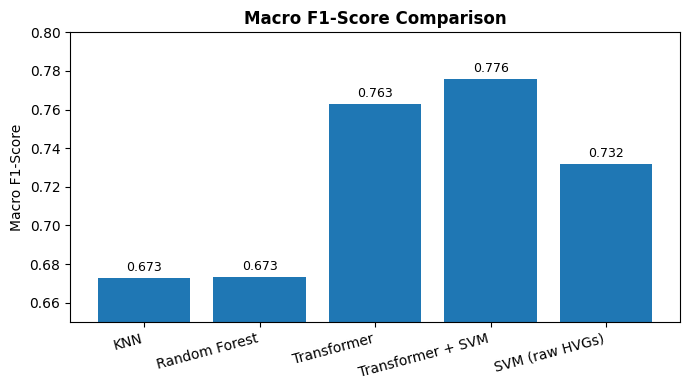

In [24]:
import matplotlib.pyplot as plt

models = ['KNN', 'Random Forest', 'Transformer', 'Transformer + SVM', 'SVM (raw HVGs)']
f1_scores = [0.6730, 0.6732, 0.7630, 0.7759, 0.7318]

plt.figure(figsize=(7, 4))
bars = plt.bar(models, f1_scores)

plt.title('Macro F1-Score Comparison', fontsize=12, weight='bold')
plt.ylabel('Macro F1-Score')
plt.ylim(0.65, 0.80)  # expanded range to fit SVM raw

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f"{bar.get_height():.3f}",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig("f1_score_comparison.png", dpi=400, bbox_inches='tight')
plt.show()

#**Show per-class misclassifications for each model**

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


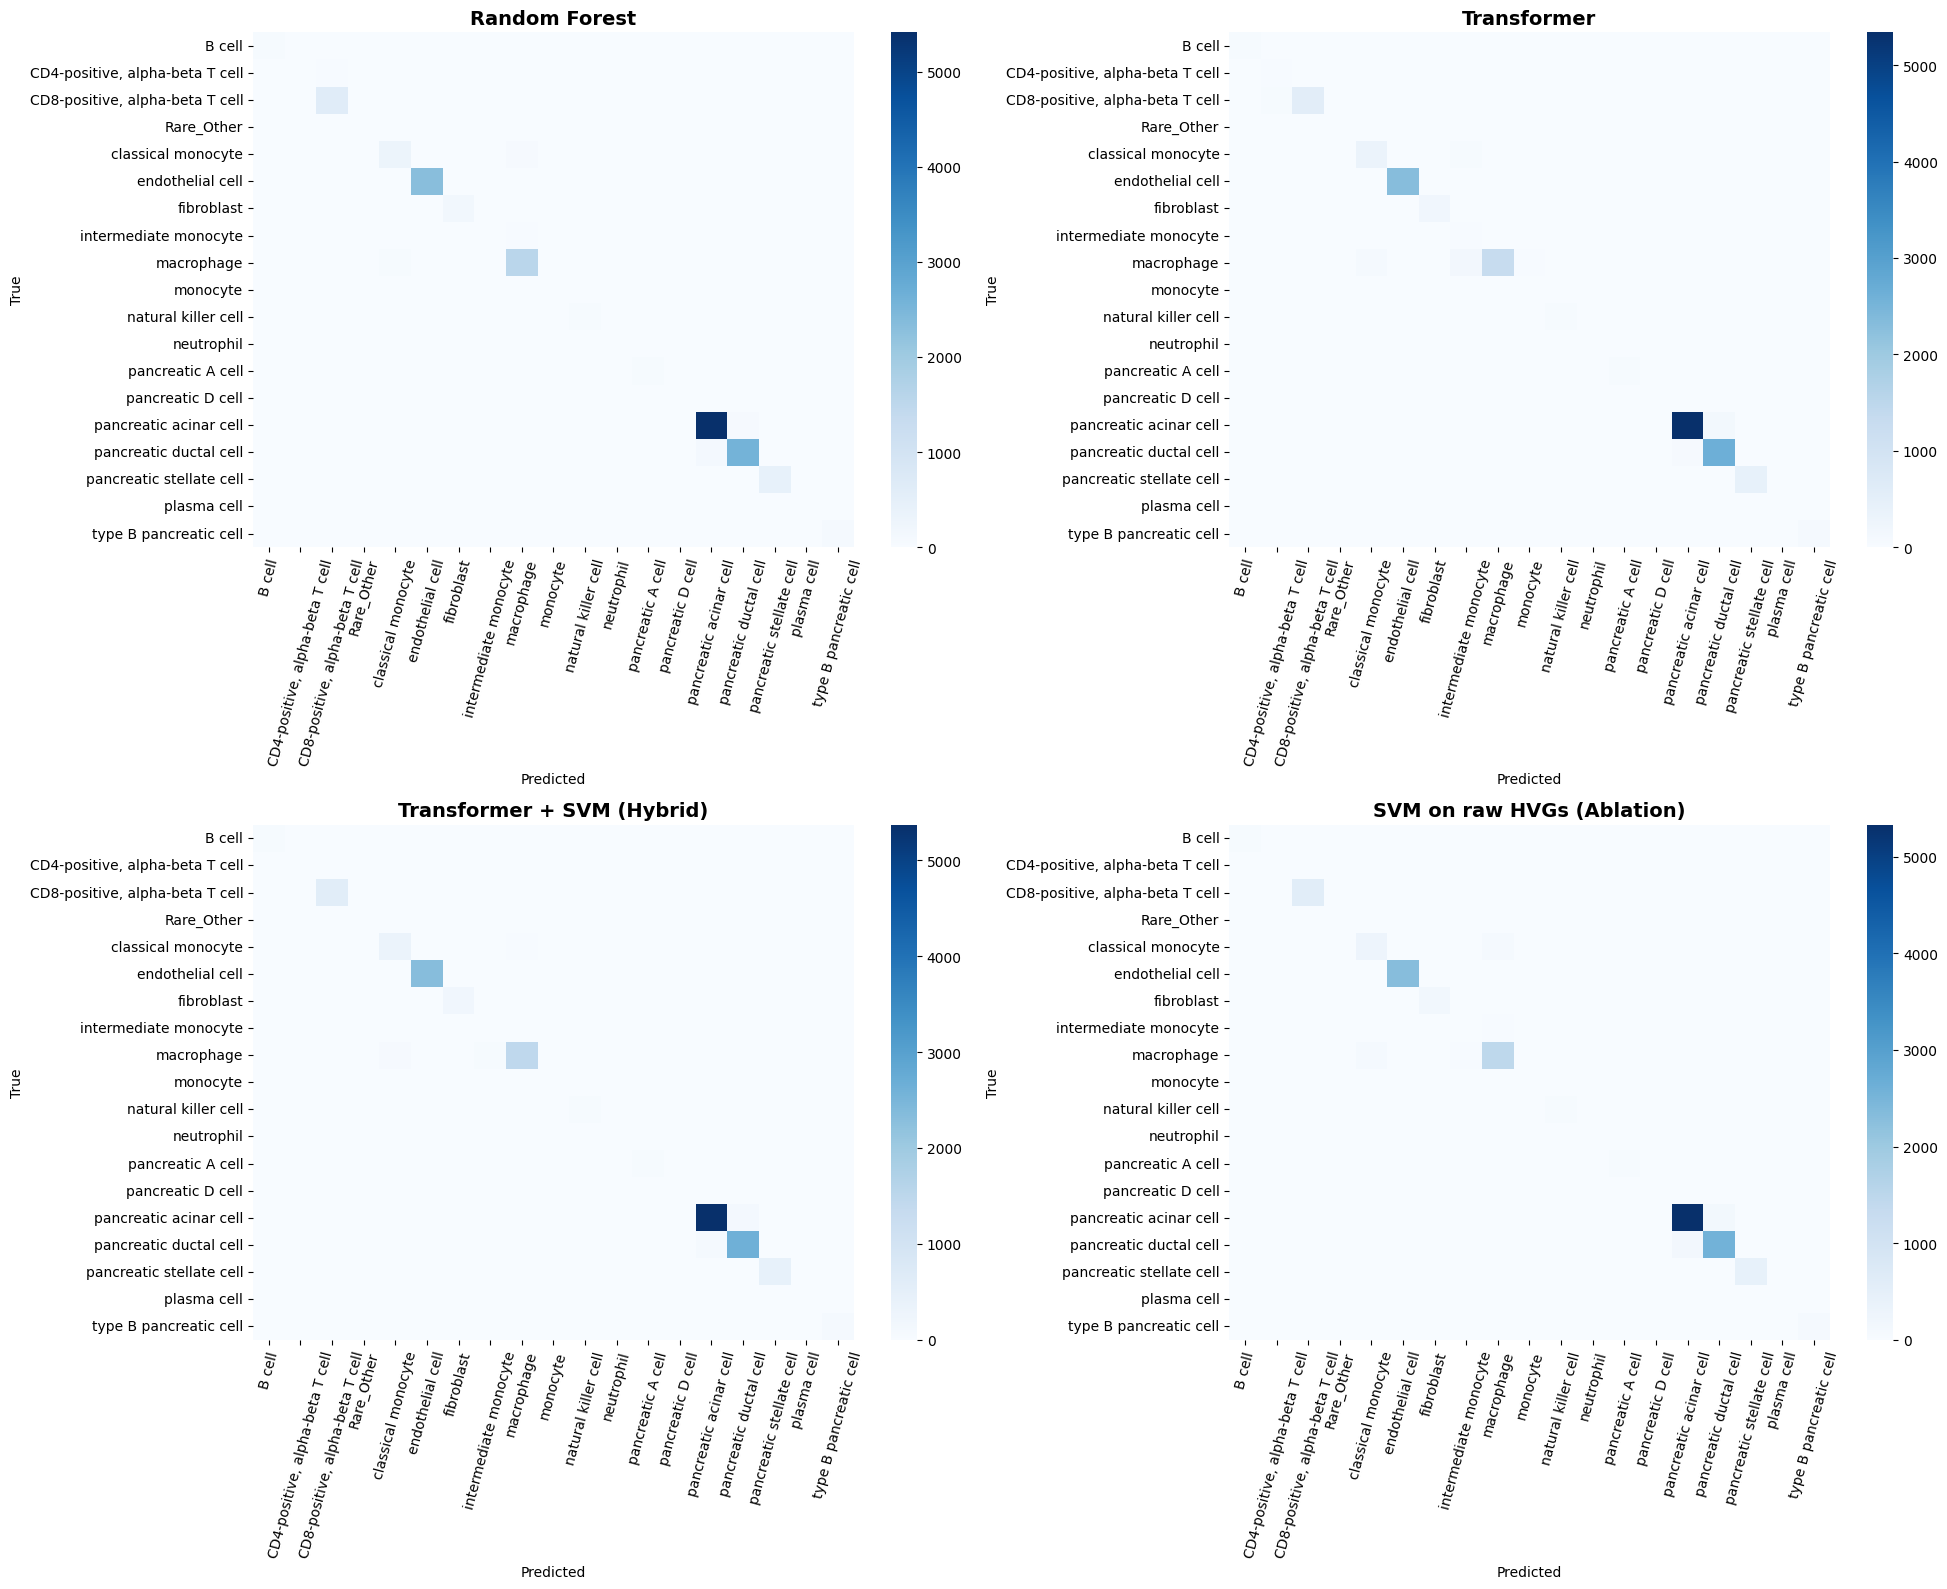

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_predict

y_true = np.asarray(y).ravel().astype(str)

y_pred_rf  = cross_val_predict(rf_pipe, X, y_true, cv=skf, n_jobs=2)
y_pred_tr  = cross_val_predict(transformer_pipe, X, y_true, cv=skf, n_jobs=2)
y_pred_hyb = cross_val_predict(transformer_svm_pipe, X, y_true, cv=skf, n_jobs=2)
y_pred_svm = cross_val_predict(svm_raw_pipe, X, y_true, cv=skf, n_jobs=2)

classes = sorted(np.unique(y_true))

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
(ax_rf, ax_tr), (ax_hyb, ax_svm) = axes

for ax, preds, title in [
    (ax_rf,  y_pred_rf,  "Random Forest"),
    (ax_tr,  y_pred_tr,  "Transformer"),
    (ax_hyb, y_pred_hyb, "Transformer + SVM (Hybrid)"),
    (ax_svm, y_pred_svm, "SVM on raw HVGs (Ablation)")
]:
    cm = confusion_matrix(y_true, preds, labels=classes)
    sns.heatmap(cm, annot=False, cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis='x', rotation=75)

plt.tight_layout()
plt.savefig("confusion_matrices_grid.png", dpi=400, bbox_inches='tight')
plt.show()